## **1ª Análise Exploratória**: Análise Inicial e Limpeza do Dataset ##

[Link do Dataset no Kaggle](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset)

In [42]:
import pandas as pd
import ast
import numpy as np

df = pd.read_csv('archive/movies_metadata.csv')

Análise Exploratória do Dataset

In [43]:
# Vamos começar conhecendo melhor as features (variáveis independentes) que possuímos
df.head(5)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45463 entries, 0 to 45462
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45463 non-null  bool   
 1   belongs_to_collection  4491 non-null   object 
 2   budget                 45463 non-null  int64  
 3   genres                 45463 non-null  object 
 4   homepage               7779 non-null   object 
 5   id                     45463 non-null  int64  
 6   imdb_id                45446 non-null  object 
 7   original_language      45452 non-null  object 
 8   original_title         45463 non-null  object 
 9   overview               44509 non-null  object 
 10  popularity             45463 non-null  float64
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [44]:
df.head(3)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92


Primeiramente, vamos eliminar algumas variáveis que não serão aplicadas ao modelo. As selecionadas foram as seguintes:

- homepage: Página de publicidade do filme
- poster_path: ID do banner do filme (Localizável em: image.tmdb.org/t/p/w185/ID)
- status: Se já foi lançado ou não (Como o Dataset é de 2017, todos os filmes já devem ter sido lançados)
- video: 

In [45]:
df.drop(['homepage', 'poster_path', 'status', 'video', 'production_companies', 'tagline'], axis=1, inplace= True)

In [46]:
df.head(3)

,adult,belongs_to_collection,budget,genres,id,imdb_id,original_language,original_title,overview,popularity,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Toy Story,7.7,5415
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Jumanji,6.9,2413
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Grumpier Old Men,6.5,92


Como podemos observar, as variáveis a seguir foram categorizadas como object, quando na realidade deveriam ser numéricas ou booleanos
- adult: Booleano (False/True)
- budget: Numérico (Dinheiro)
- release_date: Numérico (Data de Lançamento)
- popularity: Numérico (Visualizações)

In [47]:
# Conferindo se há valores além de "True" e "False" na coluna
df['adult'].unique()

array([False,  True])

In [48]:
# Substituindo as strings "True" e "False" pelos valores booleanos
df['adult'] = df['adult'] == 'True'

In [49]:
# Analisando quais são os caracteres presentes dentro da coluna budget.
df['budget'].astype(str).apply(list).explode().unique()

# Como podemos observar no Output, a coluna contém somente numerais e nenhum ponto (.), o que indica que todos os valores são números inteiros
# Isso significa que podemos seguir com a conversão para integer diretamente
df['budget'] = df['budget'].astype('Int64')

In [50]:
df['release_date'] = pd.to_datetime(df['release_date'])

In [51]:
df.head(2)

,adult,belongs_to_collection,budget,genres,id,imdb_id,original_language,original_title,overview,popularity,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Toy Story,7.7,5415
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Jumanji,6.9,2413


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45463 entries, 0 to 45462
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   adult                  45463 non-null  bool          
 1   belongs_to_collection  4491 non-null   object        
 2   budget                 45463 non-null  Int64         
 3   genres                 45463 non-null  object        
 4   id                     45463 non-null  int64         
 5   imdb_id                45446 non-null  object        
 6   original_language      45452 non-null  object        
 7   original_title         45463 non-null  object        
 8   overview               44509 non-null  object        
 9   popularity             45463 non-null  float64       
 10  production_countries   45463 non-null  object        
 11  release_date           45379 non-null  datetime64[ns]
 12  revenue                45463 non-null  int64         
 13  r

In [53]:
# Para facilitar a visualização da tipagem dos dados, vamos reorganizar a tabela
nova_ordem_colunas = [
    # Booleana
    'adult',

    # Numéricas (Inteiros)
    'id', 'budget', 'revenue', 'vote_count',

    # Numéricas (Decimais / Floats)
    'popularity', 'runtime', 'vote_average',

    # Data
    'release_date',

    # Texto / Objeto (Descritivas)
    'title', 'original_title', 'overview',

    # Texto / Objeto (Listas/Metadados)
    'genres', 'belongs_to_collection', 'production_countries', 'spoken_languages',

    # Texto / Objeto (IDs/Código)
    'imdb_id', 'original_language'
]

df = df[nova_ordem_colunas]
df.head(5)

,adult,id,budget,revenue,vote_count,popularity,runtime,vote_average,release_date,title,original_title,overview,genres,belongs_to_collection,production_countries,spoken_languages,imdb_id,original_language
0,False,862,30000000,373554033,5415,21.946943,81.0,7.7,1995-10-30,Toy Story,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","{'id': 10194, 'name': 'Toy Story Collection', ...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",tt0114709,en
1,False,8844,65000000,262797249,2413,17.015539,104.0,6.9,1995-12-15,Jumanji,Jumanji,When siblings Judy and Peter discover an encha...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,"[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",tt0113497,en
2,False,15602,0,0,92,11.712900,101.0,6.5,1995-12-22,Grumpier Old Men,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...","{'id': 119050, 'name': 'Grumpy Old Men Collect...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",tt0113228,en
3,False,31357,16000000,81452156,34,3.859495,127.0,6.1,1995-12-22,Waiting to Exhale,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,"[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",tt0114885,en
4,False,11862,0,76578911,173,8.387519,106.0,5.7,1995-02-10,Father of the Bride Part II,Father of the Bride Part II,Just when George Banks has recovered from his ...,"[{'id': 35, 'name': 'Comedy'}]","{'id': 96871, 'name': 'Father of the Bride Col...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",tt0113041,en


In [54]:
# Por último, a coluna belongs_to_collection possui 90% dos seus valores como NaN. Isso será um problema no treinamento do modelo.
# Para reverter isso, vamos desserializar os dados, convertendo todos para dicionários, incluindo os valores nulos
df['belongs_to_collection'] = df['belongs_to_collection'].apply(
    lambda x: x if pd.notna(x) else {} # Os valores NaN serão convertidos em dicionários vazios {}
)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45463 entries, 0 to 45462
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   adult                  45463 non-null  bool          
 1   id                     45463 non-null  int64         
 2   budget                 45463 non-null  Int64         
 3   revenue                45463 non-null  int64         
 4   vote_count             45463 non-null  int64         
 5   popularity             45463 non-null  float64       
 6   runtime                45206 non-null  float64       
 7   vote_average           45463 non-null  float64       
 8   release_date           45379 non-null  datetime64[ns]
 9   title                  45463 non-null  object        
 10  original_title         45463 non-null  object        
 11  overview               44509 non-null  object        
 12  genres                 45463 non-null  object        
 13  b

## **2ª Análise Exploratória**: Duração do Filme ##

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # O Seaborn facilita a criação de gráficos estatísticos e usa o Matplotlib por baixo dos panos

# Configuração básica para visualização (opcional)
sns.set_style("whitegrid") 
plt.rcParams['figure.figsize'] = (10, 6) # Define um tamanho padrão para os gráficos

Vamos usar um histograma para visualizar qual a duração mais comuns dos filmes presentes no Dataset

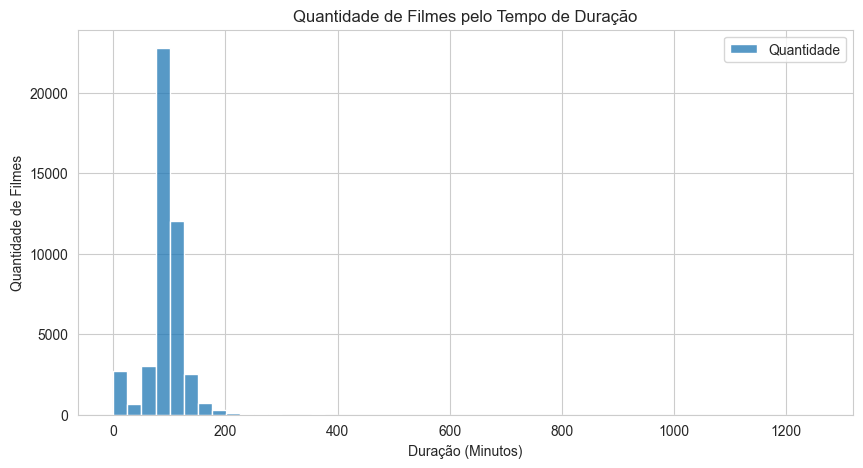

In [57]:
# Histograma: Mostra a distribuição de uma única variável
plt.figure(figsize=(10, 5))
sns.histplot(df['runtime'].dropna(), kde=False, bins=50) 
# Usamos dropna() para ignorar os NaNs
# kde=True adiciona uma estimativa da densidade (suaviza a curva)
plt.title('Quantidade de Filmes pelo Tempo de Duração')
plt.xlabel('Duração (Minutos)')
plt.ylabel('Quantidade de Filmes')
plt.legend(['Quantidade', 'Tempo'])
plt.show()

In [58]:
# Aqui, como temos poucas linhas NaN (cerca de 200), vamos removê-las do Dataset
df = df.dropna(subset=['runtime'])

# Vamos definir uma função que atribua uma categoria de acordo com a duração do filme
def categorizar_duracao(runtime):
    if runtime < 15:
        return "Very Short"
    
    elif 15 <= runtime < 60: # < 1hr
        return "Short"
    
    elif 60 <= runtime < 90: # De 1 a 1,5
        return "Short-Medium"
    
    elif 90 <= runtime < 120: # De 1,5 a 2
        return "Medium-Long"
    
    elif 120 <= runtime < 180: # De 2 a 3
        return "Long"
    
    elif 180 <= runtime: # > 3
        return "Very Long"
    
# Aqui aplicamos a função sobre a coluna runtime, criando a nova coluna Categoria de Duração
df['runtime_category'] = df['runtime'].apply(categorizar_duracao)

runtime_category
Medium-Long     24155
Short-Medium    11519
Long             5004
Very Short       2392
Short            1540
Very Long         596
Name: count, dtype: int64


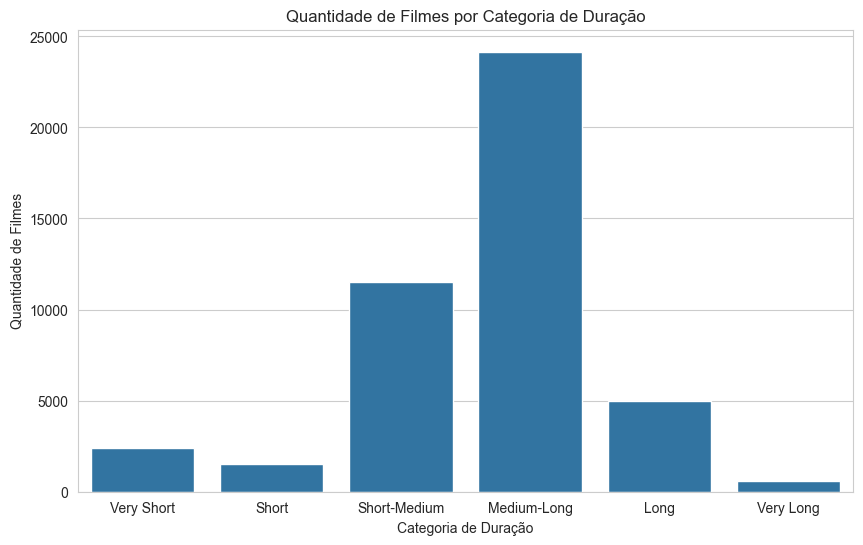

In [59]:
# Imprimir uma tabelinha com as contagens de cada categoria
print(df['runtime_category'].value_counts())

# Como estamos trabalhando com variáveis categóricas agora, vamos usar uma countplot
sns.countplot(data=df, x='runtime_category', order=['Very Short', 'Short', 'Short-Medium', 'Medium-Long', 'Long', 'Very Long' ])
plt.title('Quantidade de Filmes por Categoria de Duração')
plt.xlabel('Categoria de Duração')
plt.ylabel('Quantidade de Filmes')

plt.show()

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45206 entries, 0 to 45462
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   adult                  45206 non-null  bool          
 1   id                     45206 non-null  int64         
 2   budget                 45206 non-null  Int64         
 3   revenue                45206 non-null  int64         
 4   vote_count             45206 non-null  int64         
 5   popularity             45206 non-null  float64       
 6   runtime                45206 non-null  float64       
 7   vote_average           45206 non-null  float64       
 8   release_date           45133 non-null  datetime64[ns]
 9   title                  45206 non-null  object        
 10  original_title         45206 non-null  object        
 11  overview               44509 non-null  object        
 12  genres                 45206 non-null  object        
 13  belong

## **3ª Análise Exploratória**: Popularidade do Filme vs. Nota Média ##


Conforme é explicado no próprio [site](https://developer.themoviedb.org/docs/popularity-and-trending) da The Movie Database, a métrica de popularidade é um indicador dinâmico que reflete: quantidade de votos; quantas vezes o filme foi favoritado; quantas vezes foi adicionado à "Watchlist"

In [61]:
df[['original_title','popularity','vote_average']].sort_values('popularity', ascending=False)

,original_title,popularity,vote_average
30698,Minions,547.488298,6.4
33354,Wonder Woman,294.337037,7.2
42219,Beauty and the Beast,287.253654,6.8
43641,Baby Driver,228.032744,7.2
24454,Big Hero 6,213.849907,7.8
...,...,...,...
20102,Electile Dysfunction: Inside the Business of A...,0.000000,0.0
24415,Une partie de plaisir,0.000000,0.0
16836,Das Experiment 770 - Gebären auf Befehl,0.000000,0.0
45335,The Land Where the Blues Began,0.000000,0.0


Por outro lado, a variável vote_average, que representa a nota média que o filme recebeu, também é um indicador interessante para avaliar o engajamento do telespectador.
Vamos tentar observar uma correlação entre essas duas variáveis a seguir.

In [62]:
df[['original_title','vote_average','popularity']].sort_values('vote_average', ascending=False)

,original_title,vote_average,popularity
27172,بید و باد,10.0,0.139262
24213,200 Cartas,10.0,0.122935
16681,The Misadventures of Margaret,10.0,0.196886
36075,Looking for Grace,10.0,0.224351
41801,Bella Vita,10.0,0.052588
...,...,...,...
45270,Tragedy in a Temporary Town,0.0,0.001189
45271,Carole King: Natural Woman,0.0,0.033154
45279,Dom wariatów,0.0,0.025410
3460,"Jails, Hospitals & Hip-Hop",0.0,0.009057


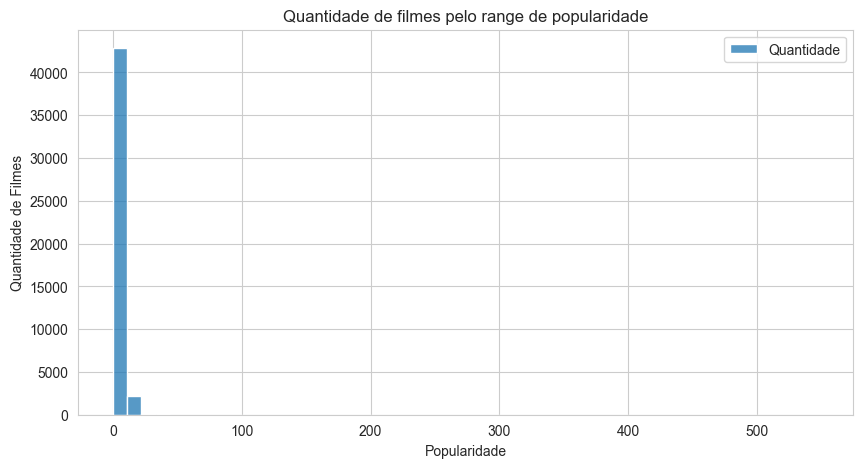

In [63]:
# Histograma: Mostra a distribuição de uma única variável
plt.figure(figsize=(10, 5))
sns.histplot(df['popularity'], kde=False, bins=50) 
# kde=True adiciona uma estimativa da densidade (suaviza a curva)
plt.title('Quantidade de filmes pelo range de popularidade')
plt.xlabel('Popularidade')
plt.ylabel('Quantidade de Filmes')
plt.legend(['Quantidade'])
plt.show()

O gráfico acima demonstra que existe uma amplitude muita alta na variável *popularity*, que varia entre 0 e 500. Para contornar isso, vamos seguir com uma **Normalização Logarítmica**, reescalonando essa feature para o intervalo de 0 a 10, sendo 10 a maior nota presente no Dataset.

In [64]:
import numpy as np

# 1. Aplicamos o log1p
log_pop = np.log1p(df['popularity'])

# 2. Reescalonamos para que o máximo seja 10
# Dividimos pelo valor máximo do log para ficar entre 0 e 1, depois multiplicamos por 10
df['popularity_norm'] = (log_pop / log_pop.max()) * 10

# Vamos ver como ficaram os valores agora:
display(df[['original_title','popularity', 'popularity_norm']].sort_values('popularity', ascending=False).head(10))

,original_title,popularity,popularity_norm
30698,Minions,547.488298,10.000000
33354,Wonder Woman,294.337037,9.018499
42219,Beauty and the Beast,287.253654,8.980009
43641,Baby Driver,228.032744,8.615383
24454,Big Hero 6,213.849907,8.514029
26563,Deadpool,187.860492,8.309609
26565,Guardians of the Galaxy Vol. 2,185.330992,8.288231
14551,Avatar,185.070892,8.286016
24350,John Wick,183.870374,8.275753
23674,Gone Girl,154.801009,8.004514


Agora sim, vamos analisar novamente o gráfico com os valores normalizados

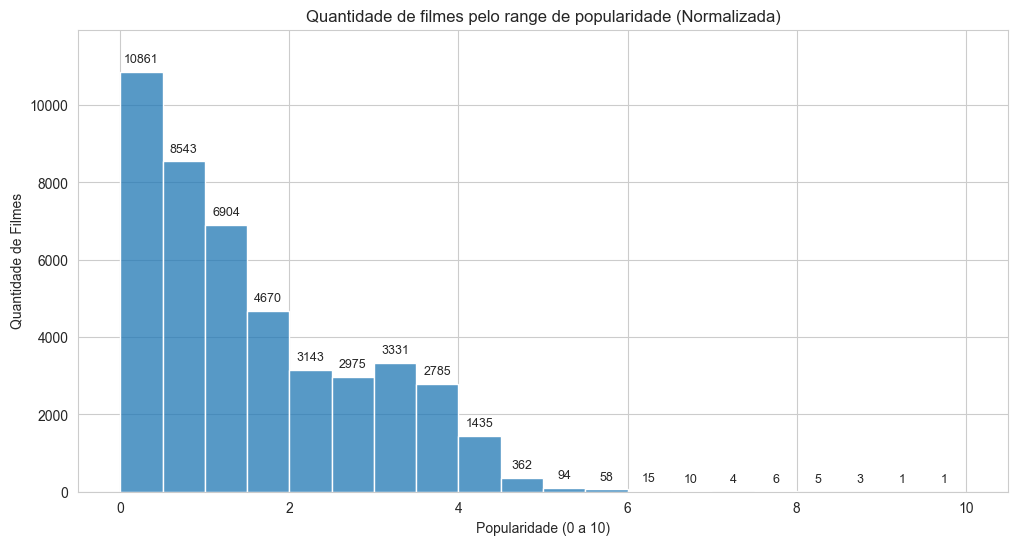

In [65]:
# Histograma: Mostra a distribuição da popularidade normalizada
plt.figure(figsize=(12, 6))
ax = sns.histplot(df['popularity_norm'], kde=False, bins=20)

# Adicionando rótulos de dados em cima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=9)

plt.title('Quantidade de filmes pelo range de popularidade (Normalizada)')
plt.xlabel('Popularidade (0 a 10)')
plt.ylabel('Quantidade de Filmes')

# Melhorando o limite do eixo Y para o texto não cortar no topo
plt.ylim(0, df['popularity_norm'].value_counts(bins=20).max() * 1.1)

plt.show()

Claramente existe uma enorme concentração de filmes com baixíssima popularidade, mas isso está relacionado à sua nota média? <br>

Text(0, 0.5, 'Nota Média (0 a 10)')

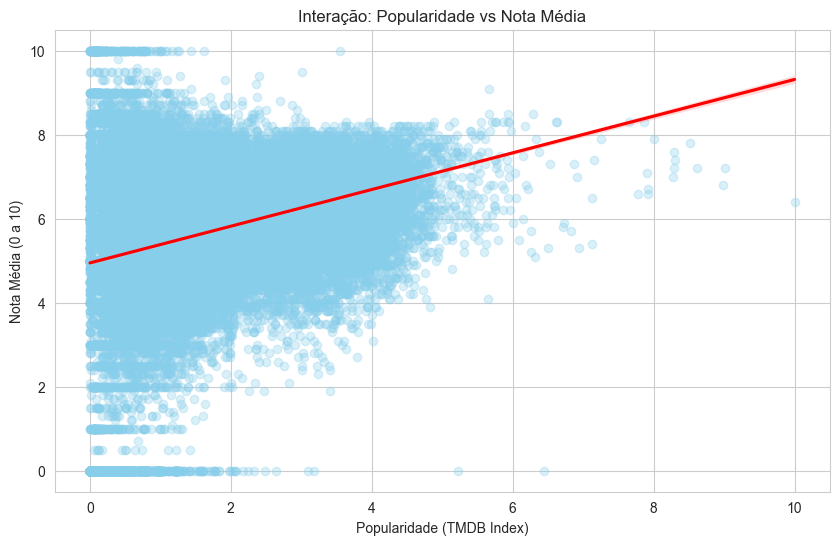

In [66]:
sns.regplot(data=df, x='popularity_norm', y='vote_average',

            scatter_kws={'alpha':0.3, 'color':'skyblue'},

            line_kws={'color':'red'})

plt.title('Interação: Popularidade vs Nota Média')

plt.xlabel('Popularidade (TMDB Index)')

plt.ylabel('Nota Média (0 a 10)')

Conforme imaginamos, o gráfico apresentado acima demonstra que existe uma linearidade considerável entre as *features popularity* e *note_average*.<br>
No entanto, devido ao gráfico ser todo da mesma cor, ainda não foi possível ver onde há maior concentração de filmes. Vamos analisar no gráfico a seguir.

Porcentagem do Dataset Analisado: 1.0
Filmes incluidos no filtro: 45206/45206


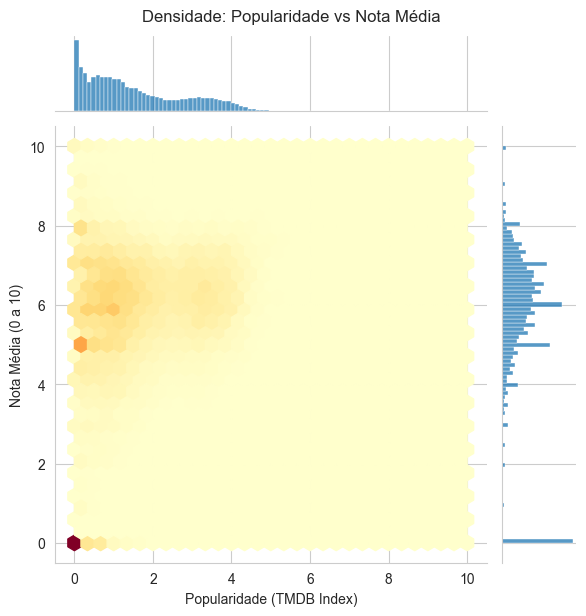

In [67]:
# Filtro simples
# df_analise = df.loc[df['popularity_norm'] > 0.5]
df_analise = df

pct_dataset_analisado = round(len(df_analise)/len(df),5)
print('Porcentagem do Dataset Analisado:',pct_dataset_analisado)
print('Filmes incluidos no filtro:', f"{len(df_analise)}"+f"/{len(df)}")

# O jointplot cria o gráfico de dispersão com "hexágonos" de calor
# e ainda adiciona histogramas nas bordas para ver o acúmulo nos eixos
g = sns.jointplot(data=df_analise, x='popularity_norm', y='vote_average',
                  kind='hex', cmap='YlOrRd', gridsize=30)

# Ajustando títulos e nomes de eixos
g.fig.suptitle('Densidade: Popularidade vs Nota Média', y=1.02)
g.set_axis_labels('Popularidade (TMDB Index)', 'Nota Média (0 a 10)')

plt.show()

O nosso algoritmo não tem como objetivo discriminar filmes pouco conhecidos, mas sim mitigar o risco de indicar um filme mal-avaliado.<br>Vamos então analisar os impactos de remover este acúmulo de filmes encontrado próximo a 0 de popularidade e 0 de nota média.

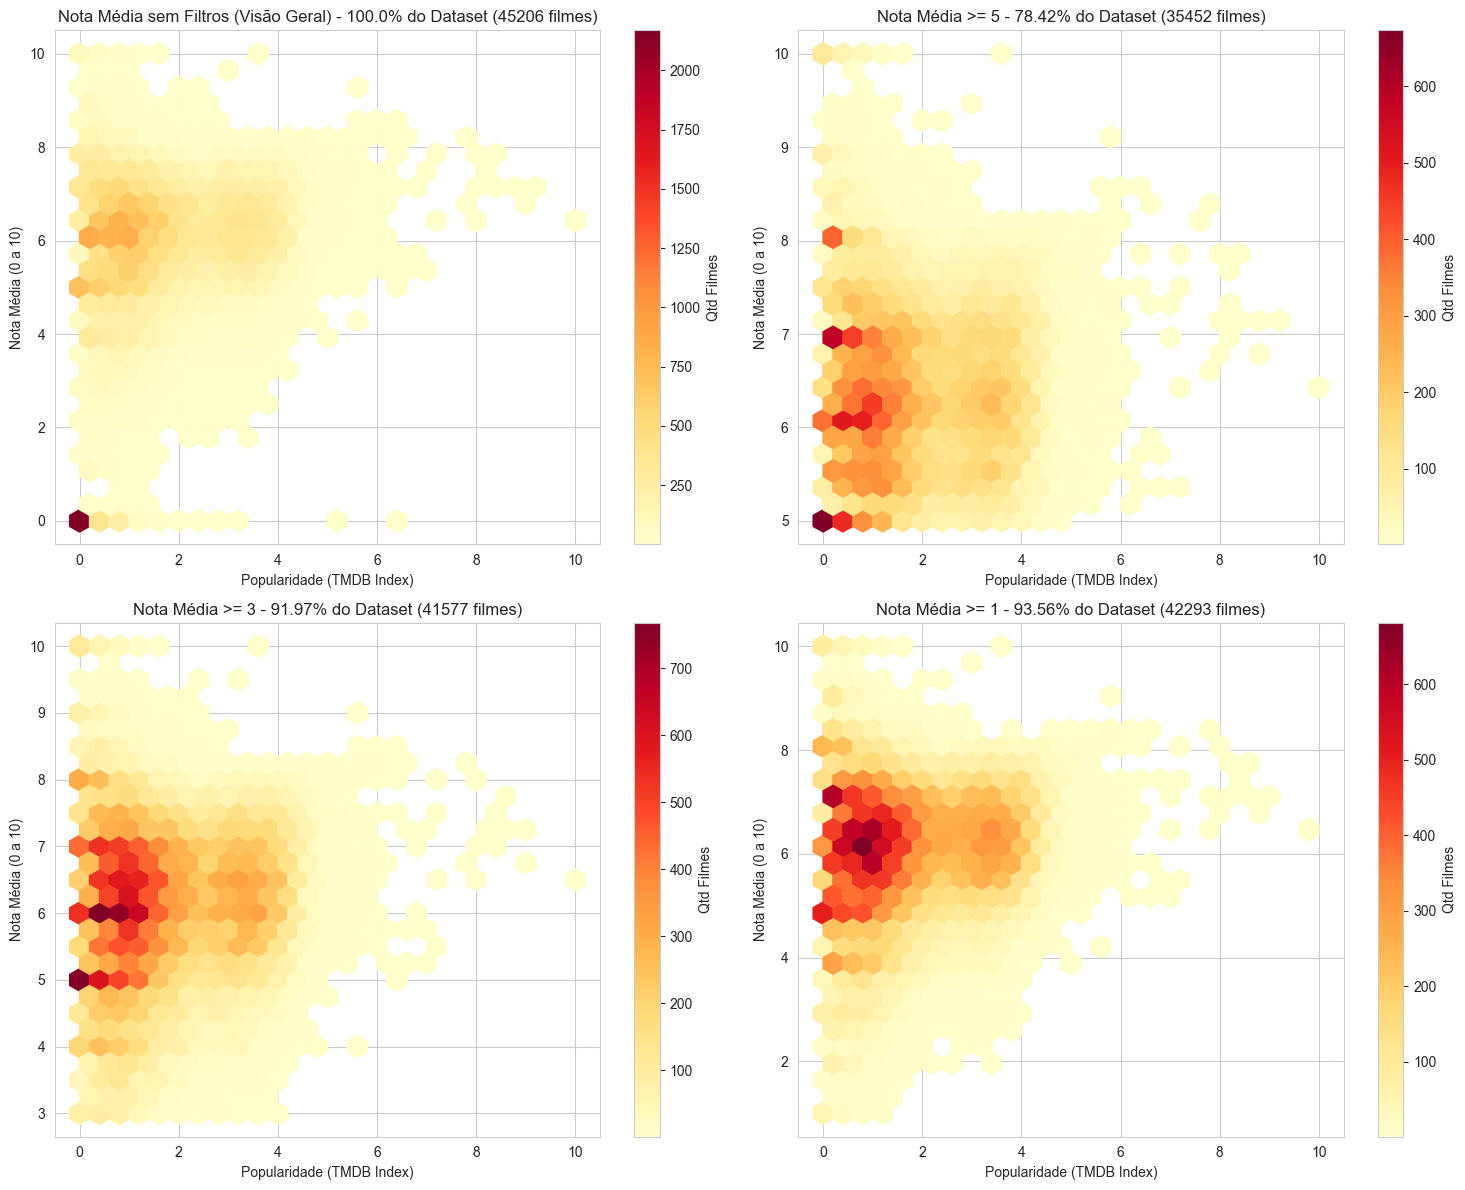

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração da figura (2x2)
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))

# --- 1. Sem filtros
df_1 = df
hb1 = axs[0, 0].hexbin(df_1['popularity_norm'], df_1['vote_average'], gridsize=25, cmap='YlOrRd', mincnt=1)
axs[0, 0].set_title(f"Nota Média sem Filtros (Visão Geral) - {round(len(df_1)/len(df)*100, 2)}% do Dataset ({len(df_1)} filmes)")
plt.colorbar(hb1, ax=axs[0, 0], label='Qtd Filmes')

# --- 2. Filtro: Nota Média > 5 ---
df_2 = df.loc[df['vote_average'] >= 5]
hb2 = axs[0, 1].hexbin(df_2['popularity_norm'], df_2['vote_average'], gridsize=25, cmap='YlOrRd', mincnt=1)
axs[0, 1].set_title(f"Nota Média >= 5 - {round(len(df_2)/len(df)*100, 2)}% do Dataset ({len(df_2)} filmes)")
plt.colorbar(hb2, ax=axs[0, 1], label='Qtd Filmes')

# --- 3. Filtro: Nota Média > 3 ---
df_3 = df.loc[df['vote_average'] >= 3]
hb4 = axs[1, 0].hexbin(df_3['popularity_norm'], df_3['vote_average'], gridsize=25, cmap='YlOrRd', mincnt=1)
axs[1, 0].set_title(f"Nota Média >= 3 - {round(len(df_3)/len(df)*100, 2)}% do Dataset ({len(df_3)} filmes)")
plt.colorbar(hb4, ax=axs[1, 1], label='Qtd Filmes')

# --- 4. Filtro: Nota Média > 1 ---
df_4 = df.loc[df['vote_average'] >= 1]
hb3 = axs[1, 1].hexbin(df_4['popularity_norm'], df_4['vote_average'], gridsize=25, cmap='YlOrRd', mincnt=1)
axs[1, 1].set_title(f"Nota Média >= 1 - {round(len(df_4)/len(df)*100, 2)}% do Dataset ({len(df_4)} filmes)")
plt.colorbar(hb3, ax=axs[1, 0], label='Qtd Filmes')

# Padronização de nomes de eixos usando o flat
for ax in axs.flat:
    if ax.axison:
        ax.set_xlabel('Popularidade (TMDB Index)')
        ax.set_ylabel('Nota Média (0 a 10)')

plt.tight_layout()
plt.show()

Aqui nos deparamos com o seguinte Trade-Off:<br>
Evidentemente quanto maior a nota de corte, menos filmes teremos disponíveis para a recomendação.<br>
A relação é a seguinte:<br>
- Nota de corte = 1 : 93,5% do dataset original : 42.293 filmes<br>
- Nota de corte = 3 : 91,9% do dataset original : 41.577 filmes<br>
- Nota de corte = 5 : 78,4% do dataset original : 35.452 filmes<br><br>
Vamos seguir com a nota de corte em 3, preservando uma biblioteca de mais de 40 mil filmes

In [69]:
# Filtrando o dataframe original para manter apenas filmes com nota média maior que 3
df = df.loc[df['vote_average'] >= 3].reset_index(drop=True)

Claramente existe uma enorme concentração de filmes com baixíssima popularidade, mas isso está relacionado à sua nota média? <br>
Para essa nova análise, vamos utilizar a **Regressão Linear** para observar essa tendência abaixo

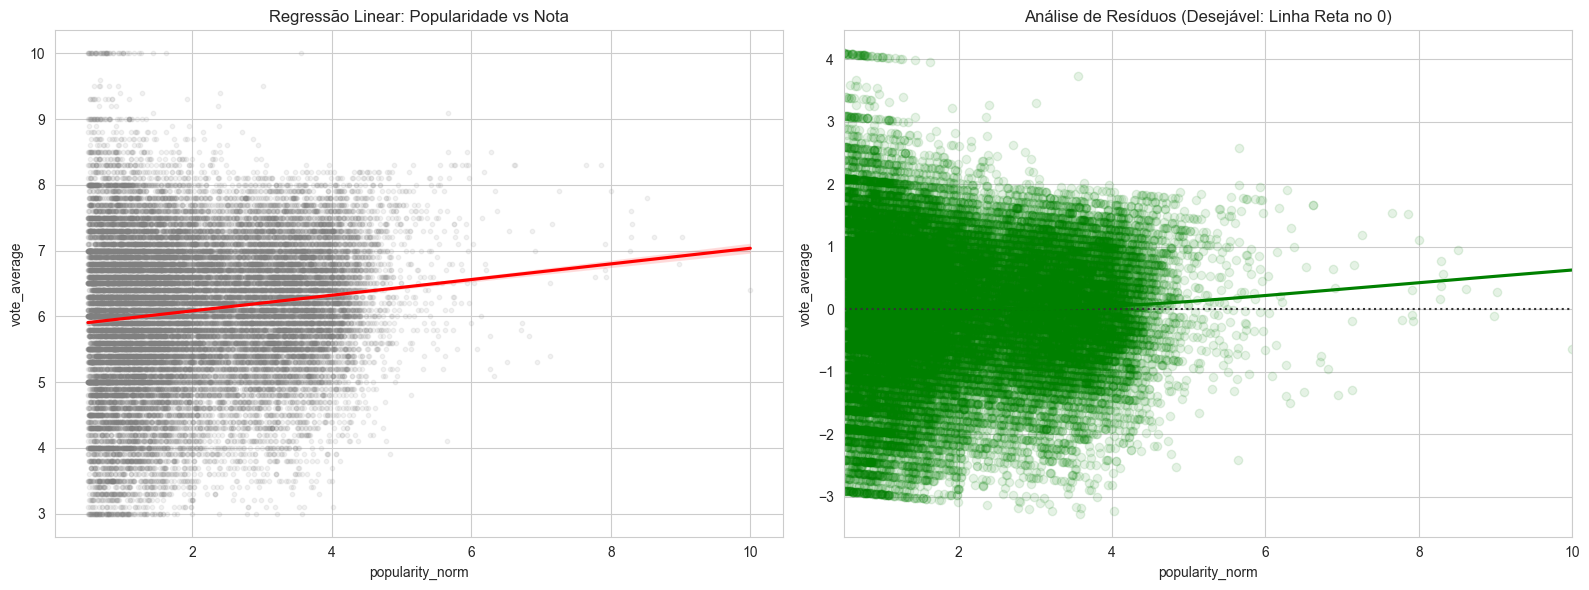

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtro para garantir dados com engajamento mínimo
df_analise = df.loc[df['popularity_norm'] > 0.5].dropna(subset=['popularity_norm', 'vote_average'])

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Regressão Linear
sns.regplot(data=df_analise, x='popularity_norm', y='vote_average', 
            scatter_kws={'alpha':0.1, 's':10, 'color':'gray'}, 
            line_kws={'color':'red'}, ax=axs[0])
axs[0].set_title('Regressão Linear: Popularidade vs Nota')

# Subplot 2: Gráfico de Resíduos (Checa se a linearidade é válida)
sns.residplot(data=df_analise, x='popularity_norm', y='vote_average', 
              lowess=True, color="g", scatter_kws={'alpha':0.1}, ax=axs[1])
axs[1].set_title('Análise de Resíduos (Desejável: Linha Reta no 0)')

plt.tight_layout()
plt.show()

O gráfico apresenta, a princípio, uma certa linearidade entre as variáveis. <br>
Porém novamente, como existe grande dispersão das notas médias apresentadas, precisamos identificar qual a confiabilidade entre a variável independente (popularidade) e variável dependente (nota média).<br>
Para isso, vamos calcular o coeficiente de Pearson (métrica estatística usada para calcular a dispersão dos pontos em torno do eixo de regressão)

In [71]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df_analise['popularity_norm'], df_analise['vote_average'])
print(f"Coeficiente de Correlação de Pearson: {corr:.4f}")
print(f"P-valor: {p_value:.4e}")

Coeficiente de Correlação de Pearson: 0.1293
P-valor: 9.9802e-125


O coeficiente de Pearson varia entre -1 e +1.<br>
Como o resultado do teste (0.12) se aproxima muito de 0, isso indica que a linearidade observada nos gráficos carrega também um erro de previsão muito alto.<br><br>
A métrica p-valor calcula o quanto podemos confiar no próprio coeficiente de Pearson de acordo com o tamanho da amostra analisada, que no caso do nosso dataset, é bem grande, com 41.577 linhas.<br>
O nosso p-valor deu 9.98 e-125. Isso equivale a 0, 125 zeros seguido de 998.<br>
Ou seja, podemos ter uma confiança bem alta de que **é muito baixa** a linearidade entre as variáveis popularity e vote_average

## **4ª Análise Exploratória**: Relação entre ROI (revenue/budget) com popularidade, nota média e quantidade de votos ##

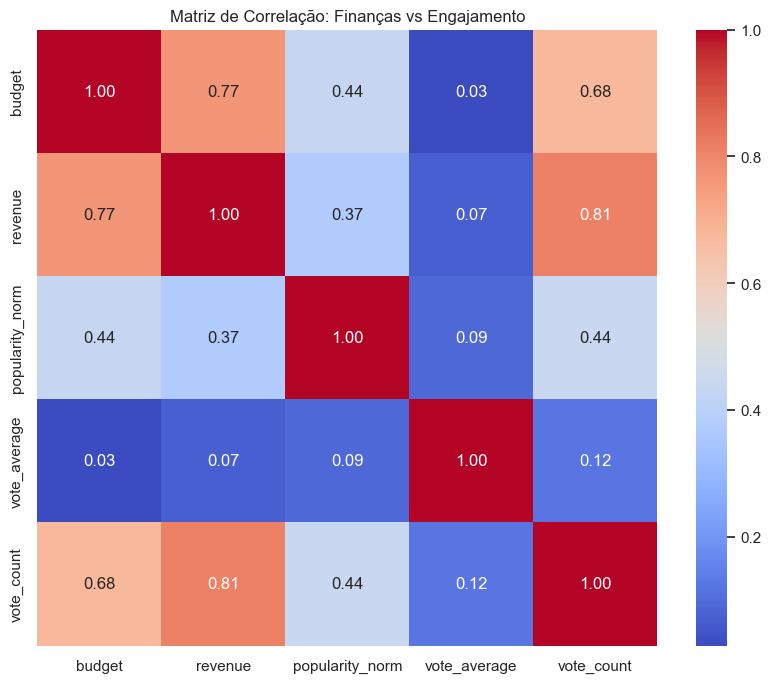

In [133]:
# Selecionando as colunas de interesse
colunas_financeiras = ['budget', 'revenue', 'popularity_norm', 'vote_average', 'vote_count']

# Calculando a correlação de Pearson para todas
matrix = df[colunas_financeiras].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação: Finanças vs Engajamento')
plt.show()

A partir do gráfico acima, podemos tirar alguns insights valiosos:
- Como já era esperado, um orçamento (budget) maior tende a alavancar a receita (revenue) do filme. Correlação de 77%.

- A quantidade de votos também tende a aumentar conforme o budget e a receita, muito provavelmente pelo montante investido com sucesso em Marketing. Correlação de 81%.

- Surpreendentemente, a correlação entre a Nota Média (vote_average) e as variáveis do ROI (orçamento e receita) é baixíssima. Isso demonstra que, na grande maioria das vezes, a avaliação positiva do público não depende de um alto investimento

A seguir, vamos analisar quais foram os 5 filmes com o maior ROI do Dataset:

In [134]:
# Calculo do ROI
df['roi'] = (df['revenue'] - df['budget']) / (df['budget'])

# Filtrando casos irreais (divisão por zero ou orçamentos simbólicos)
df_roi = df.loc[(df['budget'] > 1000) & (df['revenue'] > 0)]

print(f"Linhas remanescentes após filtro de ROI: {len(df_roi)}, {round(len(df_roi)/len(df),4)*100}% do Dataset original.")
print("Top 5 Filmes com maior ROI:")
display(df_roi[['title', 'budget', 'revenue', 'roi', 'vote_average','popularity_norm','vote_average']].sort_values('roi', ascending=False).head(5))

Linhas remanescentes após filtro de ROI: 5312, 12.78% do Dataset original.
Top 5 Filmes com maior ROI:


,title,budget,revenue,roi,vote_average,popularity_norm,vote_average
13830,Paranormal Activity,15000,193355800,12889.386667,5.9,4.150620,5.9
2486,The Blair Witch Project,60000,248000000,4132.333333,6.3,4.379838,6.3
38172,The Tiger: An Old Hunter's Tale,5000,11083449,2215.6898,7.5,2.366246,7.5
3412,Eraserhead,10000,7000000,699.0,7.5,3.460806,7.5
4152,The Way of the Dragon,130000,85000000,652.846154,7.4,3.955130,7.4


Os resultados acima nos permitem duas análises importantes:
- Somente 5312 filmes (cerca de 12%) podem participar pela ausência de dados (valores zerados)
- Filmes de terror costumam dar um grande retorno
- Vamos precisar levar em consideração o ano em que o filme foi lançado.

Em relação à última análise, podemos observar que somente 3 dos 5 filmes apresentados acima foram lançados no século passado, que possuía um mercado cinematográfico completamente diferente do de hoje. The Way of the Dragon (estrelado por Bruce Lee em 1972), por exemplo, pode ter ficado meses em cartaz no mundo todo. <br>
Portanto, para comparar maçãs com maçãs, vamos comparar o ROI do filme em questão com o ROI médio daquele ano, utilizando a variável *release_date* 

In [135]:
# Vamos começar convertendo a coluna de datas para extrair o ano de lançamento
df_roi['release_date'] = pd.to_datetime(df_roi['release_date'])
df_roi['release_year'] = df_roi['release_date'].dt.year

# 2. Calcular a média anual
# O as_index=False garante que 'release_year' continue sendo uma coluna comum
roi_medio_anual = df_roi.groupby('release_year', as_index=False)['roi'].mean()
roi_medio_anual = roi_medio_anual.rename(columns={'roi': 'roi_medio_ano'})

# 3. Mesclar (Join) as informações
df_roi = df_roi.merge(roi_medio_anual, on='release_year')

# 4. Criar o ROI Relativo
df_roi['roi_relativo'] = df_roi['roi'] / df_roi['roi_medio_ano']

# Exibir os resultados para validar
print("Top 10 Filmes com maior ROI Relativo:")
display(df_roi[['title', 'release_year', 'roi', 'roi_medio_ano', 'roi_relativo']].sort_values('roi_relativo', ascending=False).head(10))

Top 10 Filmes com maior ROI Relativo:


C:\Users\Neon Live\AppData\Local\Temp\ipykernel_22696\3551831454.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_roi['release_date'] = pd.to_datetime(df_roi['release_date'])
C:\Users\Neon Live\AppData\Local\Temp\ipykernel_22696\3551831454.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_roi['release_year'] = df_roi['release_date'].dt.year


,title,release_year,roi,roi_medio_ano,roi_relativo
3400,Paranormal Activity,2007,12889.386667,67.650391,190.529374
5153,The Tiger: An Old Hunter's Tale,2015,2215.6898,15.368187,144.173788
981,The Blair Witch Project,1999,4132.333333,32.681522,126.4425
2313,Super Size Me,2004,438.616585,8.28069,52.9686
2480,Open Water,2004,419.522723,8.28069,50.662771
2839,Facing the Giants,2006,100.78331,2.180477,46.220769
2680,Keeping Mum,2005,108.850308,2.457857,44.286673
3622,Catfish,2010,100.531433,2.764209,36.36897
3247,Fireproof,2008,65.912634,1.893394,34.811901
3922,The Devil Inside,2012,100.75849,3.203883,31.448868


Agora vamos calcular a linearidade do ROI relativo ao ano de lançamento do filme com a sua avaliação

In [139]:
import numpy as np

# 1. Ajuste para garantir que não tenhamos problemas com valores negativos
# Somamos 1 ao ROI para que o prejuízo total (-1) vire 0 antes do log
df_roi['roi_log'] = np.log1p(df_roi['roi'])

# 2. Agora calculamos a correlação com a nota
linearidade_log = df_roi['vote_average'].corr(df_roi['roi_log'])

print(f"Linearidade com ROI Bruto: {df_roi['vote_average'].corr(df_roi['roi']):.4f}")
print(f"Linearidade com ROI Logarítmico: {linearidade_log:.4f}")

Linearidade com ROI Bruto: 0.0075
Linearidade com ROI Logarítmico: 0.2691


A princípio, a linearidade do ROI bruto parecia ser quase nula (0,0075), porém, como podemos observar, após a normalização logarítmica do ROI, esse número subiu significativamente (0,2691).<br>
Vamos plotar essa correlação em um gráfico de dispersão para observar mais claramente


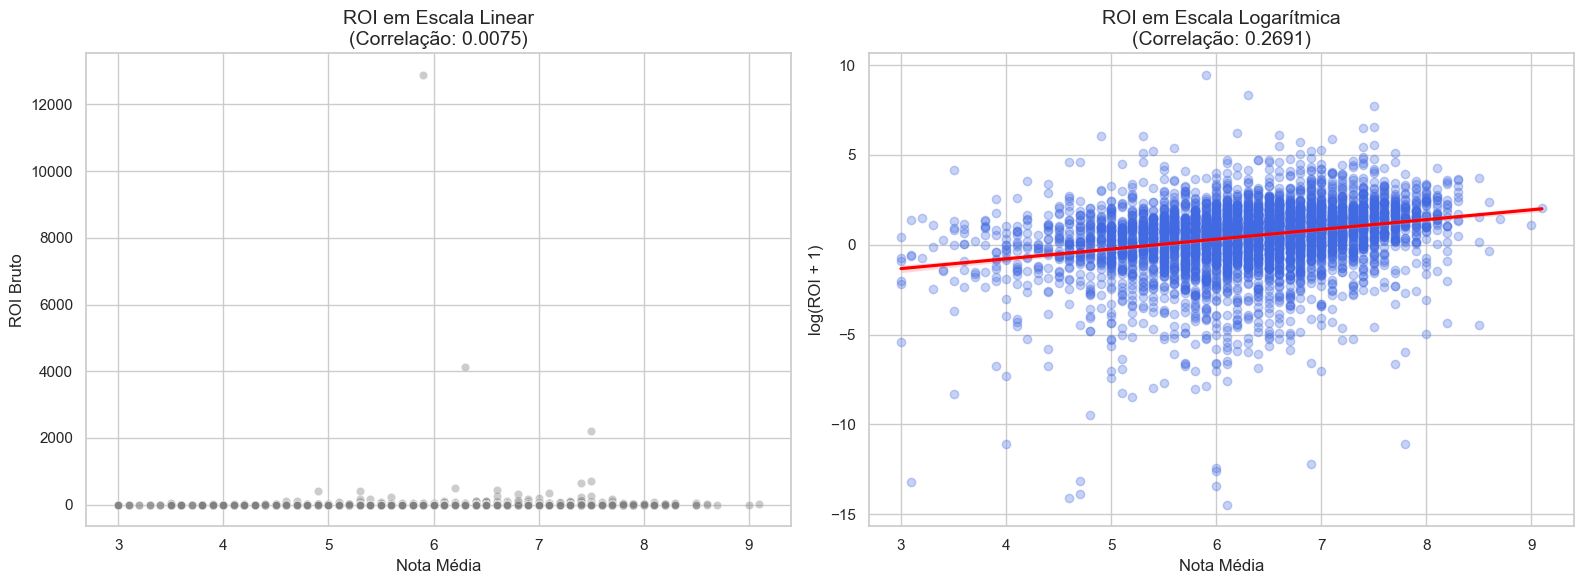

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo
sns.set_theme(style="whitegrid")

# Criando a figura com dois gráficos para comparação
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico Escala Linear (O Caos)
sns.scatterplot(data=df_roi, x='vote_average', y='roi', alpha=0.4, ax=ax1, color='gray')
ax1.set_title(f'ROI em Escala Linear\n(Correlação: 0.0075)', fontsize=14)
ax1.set_xlabel('Nota Média')
ax1.set_ylabel('ROI Bruto')

# 2. Gráfico Escala Logarítmica (A Linearidade Revelada)
# O regplot já desenha a linha de tendência da linearidade
sns.regplot(data=df_roi, x='vote_average', y='roi_log', 
            scatter_kws={'alpha':0.3, 'color':'royalblue'}, 
            line_kws={'color':'red'}, ax=ax2)

ax2.set_title(f'ROI em Escala Logarítmica\n(Correlação: 0.2691)', fontsize=14)
ax2.set_xlabel('Nota Média')
ax2.set_ylabel('log(ROI + 1)')

plt.tight_layout()
plt.show()

O gráfico à direita, que contém os valores normalizados, demonstra a correlação positiva entre o sucesso financeiro de um filme e a avaliação positiva, indicando que o ROI relativo normalizado também poderá se tornar uma featura no nosso modelo de recomendação de filmes.

## **5ª Análise Exploratória**: Relação entre o gênero, a nota média, o ROI e a popularidade. ##